# Assignment 4

Before working on this assignment please read these instructions fully. In the submission area, you will notice that you can click the link to **Preview the Grading** for each step of the assignment. This is the criteria that will be used for peer grading. Please familiarize yourself with the criteria before beginning the assignment.

This assignment requires that you find **at least two datasets** on the web which are related, and that you visualize these datasets to answer the assignment question. You are free to utilize datasets with any location or domain, the usage of **Ann Arbor sports and athletics** datasets in the example is just a suggestion.

You are welcome to choose datasets at your discretion, but keep in mind **they will be shared with your peers**, so choose appropriate datasets. Sensitive, confidential, illicit, and proprietary materials are not good choices for datasets for this assignment. You are welcome to upload datasets of your own as well, and link to them using a third party repository such as github, pastebin, etc. Please be aware of the Coursera terms of service with respect to intellectual property.

Also, you are welcome to preserve data in its original language, but for the purposes of grading you should provide english translations. You are welcome to provide multiple visuals in different languages if you would like!

As this assignment is for the whole course, you must incorporate principles discussed in the first week, such as having as high data-ink ratio (Tufte) and aligning with Cairo’s principles of truth, beauty, function, and insight.

Here are the assignment instructions:

 * You must state a question you are seeking to answer with your visualizations.
 * You must provide at least two links to available datasets. These could be links to files such as CSV or Excel files, or links to websites which might have data in tabular form, such as Wikipedia pages.
 * You must upload an image which addresses the research question you stated. In addition to addressing the question, this visual should follow Cairo's principles of truthfulness, functionality, beauty, and insightfulness.
 * You must contribute a short (1-2 paragraph) written justification of how your visualization addresses your stated research question.

## Tips
* Wikipedia is an excellent source of data, and I strongly encourage you to explore it for new data sources.
* Many governments run open data initiatives at the city, region, and country levels, and these are wonderful resources for localized data sources.
* Several international agencies, such as the [United Nations](http://data.un.org/), the [World Bank](http://data.worldbank.org/), the [Global Open Data Index](http://index.okfn.org/place/) are other great places to look for data.
* This assignment requires you to convert and clean datafiles. Check out the discussion forums for tips on how to do this from various sources, and share your successes with your fellow students!

## Example
Looking for an example? Here's what our course assistant put together as an example! [Example Solution File](./readonly/Assignment4_example.pdf)

### Region and Dominion
Bogotá,Colombia
Problematic or abusive consumption of psicoactive drugs
### Research Question
Which are the age groups with the highest percentage of problematic or abusive consumption of psicoactive drugs, for 2024, in the 5 localities with the most consumption?
### Fuentes de datos
Population of bogotá: https://datosabiertos.bogota.gov.co/dataset/piramide-poblacional-bogota-d-c 
Cases of problematic or abusive consumption of psicoactive drugs: https://datosabiertos.bogota.gov.co/dataset/50b957e1-7ee6-4a69-8fb3-d79f2b6c9f73

https://datosabiertos.bogota.gov.co/dataset/piramide-poblacional-bogota-d-c
https://datosabiertos.bogota.gov.co/dataset/numero-de-casos-de-violencia-intrafamiliar
https://datosabiertos.bogota.gov.co/dataset/50b957e1-7ee6-4a69-8fb3-d79f2b6c9f73

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sust_psicoactivas=pd.read_csv("descargable_vespa_gral.csv",sep=';')
sust_psicoactivas.head()

,ANO,SEXO,NOMBRELOCALIDADRESIDENCIA,MESNOTIFICACION,TRIMESTRE,TIPOASEGURAMIENTO,SITIOHABITUALCONSUMO_VIVIENDA,SITIOHABITUALCONSUMO_PARQUE,SITIOHABITUALCONSUMO_EST_EDUCATIVO,SITIOHABITUALCONSUMO_BARES_TABERNAS,...,SITIOHABITUALCONSUMO_CASA_AMIGOS,NIVELEDUCATIVO,CURSO_DE_VIDA,COMOACUDIOTRATAMIENTO,PERTENENCIAETNICA,ORIENTSEXUAL,PAISNACIONALIDAD,NOMBREUPZ,ESTADOCIVIL,CASOS
0,2022.0,Hombre,Ciudad Bolívar,6.0,2.0,Subsidiado,SI,SI,NO,SI,...,SI,6. Secundaria completa,Adultez,1. Voluntariamente,AfroColombianos,Homosexual,Sin Dato,LUCERO,1. Soltero (a),1
1,2022.0,Hombre,Suba,7.0,3.0,Particular,SI,NO,NO,NO,...,NO,1. No fue a la escuela,Juventud,1. Voluntariamente,Otros,Heterosexual,Sin Dato,SUBA,1. Soltero (a),1
2,2022.0,Mujer,Mártires,7.0,3.0,Contributivo,NO,SI,NO,NO,...,NO,5. Secundaria incompleta,Adolescencia,2. Lo llevaron familiares,Otros,Heterosexual,Sin Dato,LA SABANA,1. Soltero (a),1
3,2022.0,Hombre,Fontibón,11.0,4.0,Contributivo,NO,SI,NO,NO,...,NO,8. Técnico post-secundaria completa,Adultez,1. Voluntariamente,Otros,Heterosexual,Sin Dato,CAPELLANIA,1. Soltero (a),2
4,2023.0,Hombre,Mártires,1.0,1.0,Subsidiado,NO,NO,NO,NO,...,SI,5. Secundaria incompleta,Adultez,1. Voluntariamente,Otros,Heterosexual,COLOMBIA,LA SABANA,1. Soltero (a),13


In [3]:
#Filtrar las entradas sin localidad y nulos
sust_psicoactivas=sust_psicoactivas[~sust_psicoactivas['NOMBRELOCALIDADRESIDENCIA'].isin(['Sin dato','N.A.'])]
sust_psicoactivas.dropna(subset=['NOMBRELOCALIDADRESIDENCIA'],inplace=True)
#remover casos sin dato y volver la columna numerica
sust_psicoactivas['CASOS'].replace(' ',np.nan,inplace=True)
sust_psicoactivas['CASOS']=sust_psicoactivas['CASOS'].apply(pd.to_numeric)
#agrupar por año el numero de casos
sust_psico_year=sust_psicoactivas.groupby(['ANO'])['CASOS'].sum()


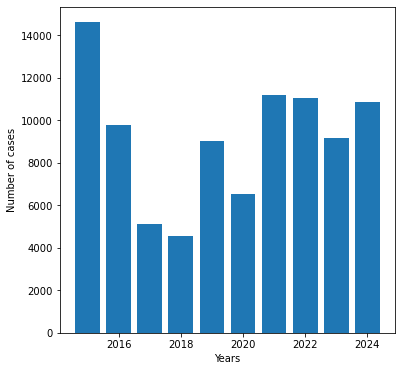

In [18]:
#Graficar el numero de casos por año
plt.figure(figsize=(6,6))
plt.bar(sust_psico_year.index,sust_psico_year)
plt.ylabel('Number of cases');
plt.xlabel('Years');

In [5]:
#Encontrar el top 5 de localidades con casos de abuso de sustancias psicoactivas
sust_psico_loc=sust_psicoactivas[sust_psicoactivas['ANO']==2024]
sust_psico_loc=sust_psico_loc.groupby(['NOMBRELOCALIDADRESIDENCIA'])['CASOS'].sum()
sust_psico_loc.sort_values(ascending=False,inplace=True)
sust_psico_loc.head(5)

NOMBRELOCALIDADRESIDENCIA
Kennedy           1185
Engativá          1107
Suba               976
Bosa               903
Ciudad Bolívar     838
Name: CASOS, dtype: int64

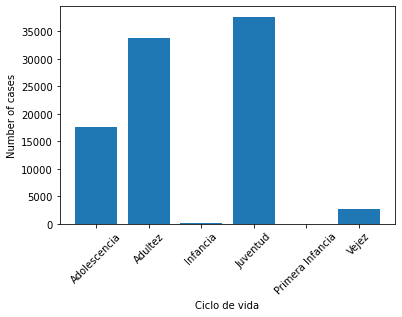

In [6]:
#Casos por ciclo de vida
sust_psico_ciclo=sust_psicoactivas.groupby(['CURSO_DE_VIDA'])['CASOS'].sum()
#sust_psico_year=sust_psicoactivas.groupby(['ANO'])['CASOS'].sum()
plt.figure()
plt.bar(sust_psico_ciclo.index,sust_psico_ciclo)
x = plt.gca().xaxis
for item in x.get_ticklabels():
    item.set_rotation(45)
plt.ylabel('Number of cases');
plt.xlabel('Ciclo de vida');

In [7]:
cases_by_age_loc=sust_psicoactivas[sust_psicoactivas['ANO']==2024]
cases_by_age_loc=sust_psicoactivas.groupby(['NOMBRELOCALIDADRESIDENCIA','CURSO_DE_VIDA'])['CASOS'].sum()
cases_by_age_loc=cases_by_age_loc.reset_index()
cases_by_age_loc

,NOMBRELOCALIDADRESIDENCIA,CURSO_DE_VIDA,CASOS
0,Antonio Nariño,Adolescencia,94
1,Antonio Nariño,Adultez,597
2,Antonio Nariño,Juventud,462
3,Antonio Nariño,Vejez,85
4,Barrios Unidos,Adolescencia,182
...,...,...,...
90,Usme,Adolescencia,2208
91,Usme,Adultez,1101
92,Usme,Infancia,17
93,Usme,Juventud,2207


In [8]:
poblacion=pd.read_csv("osb_demografia-poblacion-localidad.csv", sep=';',encoding='latin-1')
poblacion_2024=poblacion[poblacion['Año']==2024]

def age_group(age):
    if age>=0 and age<=5:
        return 'Primera Infancia'
    elif age>=6 and age <=11:
        return 'Infancia'
    elif age>=12 and age<=16:
        return 'Adolescencia'
    elif age >=17 and age <=26:
        return 'Juventud'
    elif age>=27 and age<=59:
        return 'Adultez'
    else:
        return 'Vejez'


In [9]:
poblacion_2024['age_group']=poblacion_2024['Edad'].apply(age_group)
poblacion_2024['Localidad'].replace('Bogotá',np.nan,inplace=True)
poblacion_2024.dropna(subset=['Localidad'],inplace=True)
#poblacion_2024.sort_values(by=['Población'],ascending=False,inplace=True)
population_age_loc=poblacion_2024.groupby(['Localidad','age_group'])['Población'].sum()
population_age_loc=population_age_loc.reset_index()
population_age_loc

,Localidad,age_group,Población
0,Antonio Nariño,Adolescencia,4620
1,Antonio Nariño,Adultez,39247
2,Antonio Nariño,Infancia,4843
3,Antonio Nariño,Juventud,12556
4,Antonio Nariño,Primera Infancia,9181
...,...,...,...
115,Usme,Adultez,183713
116,Usme,Infancia,35975
117,Usme,Juventud,69428
118,Usme,Primera Infancia,44135


In [10]:
#Union de data sets para grafica final 
sust_pop_age_loc=population_age_loc.merge(cases_by_age_loc, how='left', left_on=['Localidad','age_group'],right_on=['NOMBRELOCALIDADRESIDENCIA','CURSO_DE_VIDA'])
sust_pop_age_loc=sust_pop_age_loc.groupby(['Localidad','age_group']).sum()
#calculo del porcentaje de casos y organizar valores, descartar los valores de primera infancia
sust_pop_age_loc['casos_poblacion']=sust_pop_age_loc['CASOS']/sust_pop_age_loc['Población']*100
sust_pop_age_loc=sust_pop_age_loc.reset_index()
sust_pop_age_loc=sust_pop_age_loc[sust_pop_age_loc['Localidad'].isin(['Kennedy','Engativá','Suba','Bosa','Ciudad Bolívar'])]
custom_dict={'Primera Infancia':0,'Infancia':1,'Adolescencia':2,'Juventud':3, 'Adultez':4,'Vejez':5}
sust_pop_age_loc=sust_pop_age_loc.pivot(index='age_group',columns='Localidad',values='casos_poblacion')
sust_pop_age_loc.sort_index(key=lambda x: x.map(custom_dict),ascending=False,inplace=True)
sust_pop_age_loc=sust_pop_age_loc[~sust_pop_age_loc.index.isin(['Primera Infancia'])]
age_groups={'Infancia':'Infancy','Adolescencia':'Adolescence','Juventud':'Youth','Adultez':'Adulthood','Vejez':'Elderly'}
sust_pop_age_loc.rename(age_groups,axis='index',inplace=True)

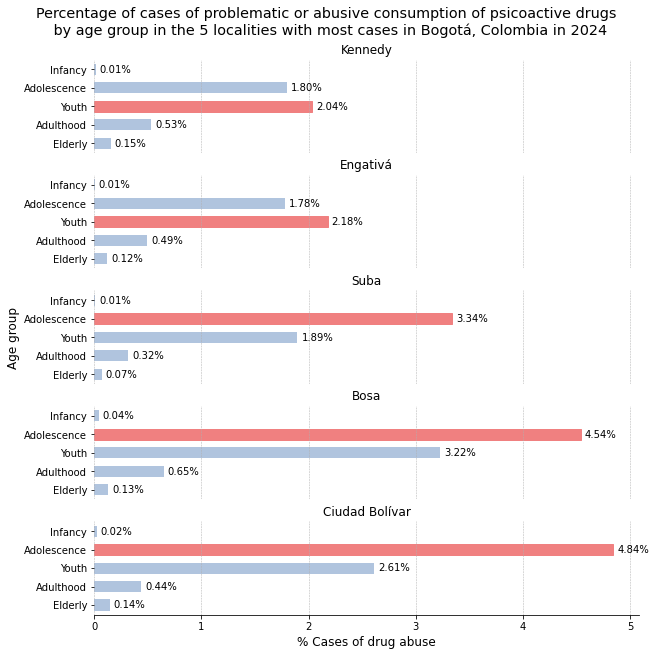

In [17]:
figure,axs=plt.subplots(nrows=5, sharex=True, sharey=True,figsize=(9,9),constrained_layout=True,facecolor='white')

figure.suptitle('Percentage of cases of problematic or abusive consumption of psicoactive drugs \n by age group in the 5 localities with most cases in Bogotá, Colombia in 2024', fontsize='x-large')

plt.subplot(5, 1, 1)
bar1=plt.barh(sust_pop_age_loc.index,sust_pop_age_loc['Kennedy'],height=.6,color='lightsteelblue')
bar1[2].set_color('lightcoral')
plt.title('Kennedy');
plt.grid(which='both', linestyle='--', linewidth=0.5,axis='x')
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
plt.bar_label(axs[0].containers[0], label_type='edge',padding=4,fmt='%0.2f%%')

plt.subplot(5, 1, 2)
bar2=plt.barh(sust_pop_age_loc.index,sust_pop_age_loc['Engativá'],height=.6,color='lightsteelblue')
bar2[2].set_color('lightcoral')
plt.title('Engativá');
plt.grid(which='both', linestyle='--', linewidth=0.5,axis='x')
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
plt.bar_label(axs[1].containers[0], label_type='edge',padding=4,fmt='%0.2f%%')

plt.subplot(5, 1, 3)
bar3=plt.barh(sust_pop_age_loc.index,sust_pop_age_loc['Suba'],height=.6,color='lightsteelblue')
bar3[3].set_color('lightcoral')
plt.ylabel('Age group',fontsize='large');
plt.title('Suba');
plt.grid(which='both', linestyle='--', linewidth=0.5,axis='x')
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
plt.bar_label(axs[2].containers[0], label_type='edge',padding=4,fmt='%0.2f%%')

plt.subplot(5, 1, 4)
bar4=plt.barh(sust_pop_age_loc.index,sust_pop_age_loc['Bosa'],height=.6,color='lightsteelblue')
bar4[3].set_color('lightcoral')
plt.title('Bosa');
plt.grid(which='both', linestyle='--', linewidth=0.5,axis='x')
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
plt.bar_label(axs[3].containers[0], label_type='edge',padding=4,fmt='%0.2f%%')

plt.subplot(5, 1, 5)
bar5=plt.barh(sust_pop_age_loc.index,sust_pop_age_loc['Ciudad Bolívar'],height=.6,color='lightsteelblue')
bar5[3].set_color('lightcoral')
plt.xlabel('% Cases of drug abuse',fontsize='large')
plt.title('Ciudad Bolívar');
for spine in ['right', 'top','left']:
    plt.gca().spines[spine].set_visible(False)
plt.bar_label(axs[4].containers[0], label_type='edge',padding=4,fmt='%0.2f%%')
    
plt.grid(which='both', linestyle='--', linewidth=0.5,axis='x')
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=True,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=True) # labels along the bottom edge are off
#axs[0].set_title('Kennedy', color='black', rotation='vertical',x=1,y=0.5);
plt.savefig('FinalAssignment.png',bbox_inches='tight');

This visualization was concerned with answering the question of which age groups present the higher percentage of cases of problematic or abusive consumption of psicoactive drugs for the localities in Bogotá with the highest overall cases( Kennedy, Engativa, Suba, Bosa and Ciudad Bolivar). The data was taken from the open data page of the city, in the psicoactive drugs dataset the cases were the localitie was unknown where dropped and in the populatino dataset a new field was added to calculate the percentage of cases per age group reported for problematic or abusive consumption of psicoactive drugs. The age group with the higher percentage was highlited in a different color for each locality.

The plor indicates the age groups for which the percentage of cases where higher, in the case of Kennedy an Engativa this corresponds to youth(ages 17-26) and for Suba, Bosa and Ciudad Bolivar the adolescence age group(ages 12-16). In all cases this percentages are followed by the Adulthood group(27-59).

